Data Cleaning:
- Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [10]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [11]:
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [33]:
df = pd.read_csv('amazonreviews.tsv',sep='\t')

In [34]:
df.shape

(10000, 2)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [36]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [37]:
df['label'].unique()

array(['pos', 'neg'], dtype=object)

In [38]:
df.isnull().sum()

,0
label,0
review,0


No null values

In [39]:
df.duplicated().sum()

np.int64(0)

No duplicate values

In [40]:
## Stopwords set
stop_words = set(stopwords.words('english'))

In [41]:
df['review']

,review
0,Stuning even for the non-gamer: This sound tra...
1,The best soundtrack ever to anything.: I'm rea...
2,Amazing!: This soundtrack is my favorite music...
3,Excellent Soundtrack: I truly like this soundt...
4,"Remember, Pull Your Jaw Off The Floor After He..."
...,...
9995,A revelation of life in small town America in ...
9996,Great biography of a very interesting journali...
9997,Interesting Subject; Poor Presentation: You'd ...
9998,Don't buy: The box looked used and it is obvio...


In [42]:

## Lowercase
df['cleaned_review']= df['review'].str.lower()

In [43]:
print(type(df['cleaned_review'][0]))

<class 'str'>


In [44]:
## Remove punctuations
df['cleaned_review'] = df['cleaned_review'].str.replace(f"[{string.punctuation}]","",regex=True)

In [45]:
## Tokenization
df['cleaned_review'] = df['cleaned_review'].apply(word_tokenize)

In [47]:
## Remove stopwords
df['cleaned_review'] = df['cleaned_review'].apply(lambda words: [word for word in words if word  not in stop_words])

In [48]:
## Join words
df['cleaned_review'] = df['cleaned_review'].apply(lambda words: " ".join(words))

In [49]:
df.head()

,label,review,cleaned_review
0,pos,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,pos,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,pos,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,pos,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


Exploratory Analysis:
- Word clouds, sentiment distribution, most common positive/negative words.

In [51]:
import wordcloud
from wordcloud import WordCloud,STOPWORDS

In [54]:
## Join complete row into ne string
text = " ".join(df['cleaned_review'])

In [55]:
word = WordCloud(width=1000,height=1000,background_color='white',stopwords=stop_words).generate(text)

In [56]:
def word_cloud(image):
  plt.figure(figsize=(10,10))
  plt.imshow(image)
  plt.axis('off')
  plt.savefig('WordCloud.png',format='png')

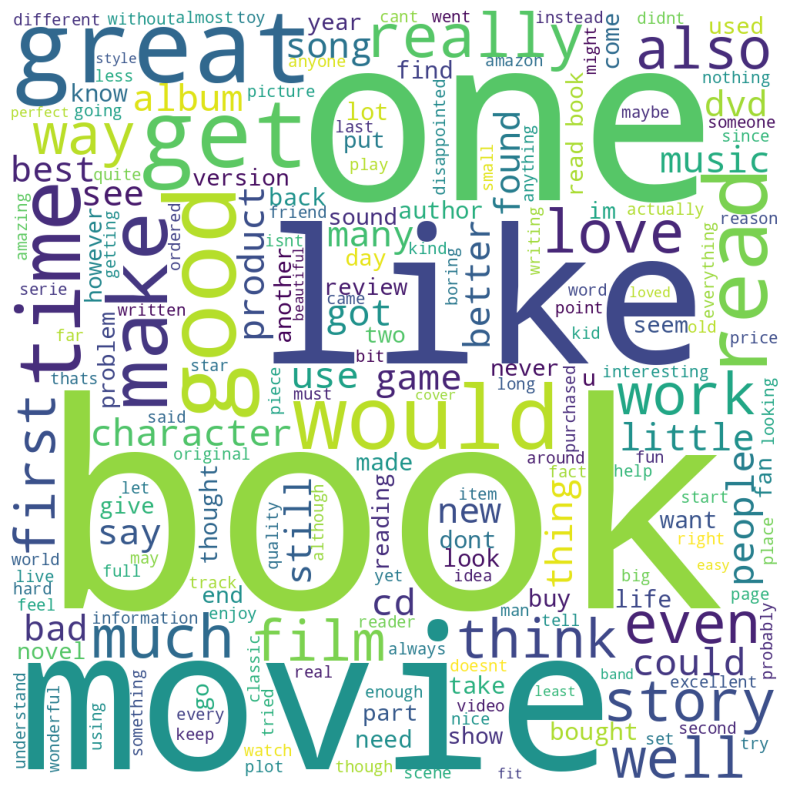

In [57]:
word_cloud(word)

In the image the biggest words is the more frequent word in the string. The smallest word is the less frequent word.

In [60]:
## Sentiment distribution
sentiment_words = df['label'].value_counts()
sentiment_words

,count
label,
neg,5097
pos,4903


In [64]:
from collections import Counter

In [61]:
## Common positive words
positive_reviews = df[df['label'] == 'pos']['cleaned_review']
positive_text = " ".join(positive_reviews)
positive_words = positive_text.split()
positive_common = Counter(positive_words).most_common(10)
print(positive_common)

[('book', 3313), ('great', 2087), ('one', 1835), ('good', 1634), ('read', 1553), ('like', 1268), ('movie', 1079), ('would', 943), ('love', 902), ('time', 871)]


In [66]:
## Common negative words
negative_reviews = df[df['label'] == 'neg']['cleaned_review']
negative_text = " ".join(negative_reviews)
negative_words = negative_text.split()
negative_common = Counter(negative_words).most_common(10)
print(negative_common)

[('book', 3183), ('one', 2022), ('like', 1546), ('movie', 1464), ('would', 1438), ('dont', 1240), ('read', 1187), ('get', 1139), ('good', 1134), ('time', 1032)]


Model Development:
- Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.


In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [67]:
target = df['label']
feature = df['cleaned_review']

In [68]:
target.head()

,label
0,pos
1,pos
2,pos
3,pos
4,pos


In [69]:
feature.head()

,cleaned_review
0,stuning even nongamer sound track beautiful pa...
1,best soundtrack ever anything im reading lot r...
2,amazing soundtrack favorite music time hands i...
3,excellent soundtrack truly like soundtrack enj...
4,remember pull jaw floor hearing youve played g...


In [72]:
## Conversion of text to numbers
vectorizer = TfidfVectorizer(max_features=5000)
x_tfidf = vectorizer.fit_transform(feature)

In [76]:
## Train test splitting
x_train,x_test,y_train,y_test = train_test_split(x_tfidf,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 5000)
(2000, 5000)
(8000,)
(2000,)


In [90]:
## Model 1 using logistic regression

In [77]:
## Model training
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)

LogisticRegression()

In [78]:
y_pred = log_reg.predict(x_test)
accuracy_score(y_test,y_pred)

0.855

In [79]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         neg       0.85      0.85      0.85       991
         pos       0.86      0.86      0.86      1009

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



Classification report shows that,
- Balanced performance
- No class bias
- Works equally well for both classes

In [84]:
## Model 2

In [80]:
from sklearn.svm import SVC

In [81]:
svc = SVC()
svc.fit(x_train,y_train)

SVC()

In [82]:
y_pred1 = svc.predict(x_test)
accuracy_score(y_test,y_pred1)

0.8605

In [83]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

         neg       0.86      0.86      0.86       991
         pos       0.86      0.86      0.86      1009

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



Classification report shows that,
- Perfectly balanced
- Slight improvement over Logistic Regression

Validation:
- Use train/test split, cross-validation, and metrics like accuracy, F1-score.

In [85]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

In [87]:
## Logistic Regression model cross validation
scores = cross_val_score(log_reg,x_tfidf,target,cv=5)
print(scores)

[0.8595 0.834  0.8265 0.828  0.849 ]


In [89]:
## SVM model cross validation score
scores1 = cross_val_score(svc,x_tfidf,target,cv=5)
print(scores1)

[0.854  0.833  0.826  0.8295 0.8505]


Conclusion :

Both Logistic Regression and Support Vector Machine models were trained using TF-IDF features. The SVM model achieved slightly higher accuracy (86.05%) compared to Logistic Regression (85.5%). However, both models showed consistent performance across cross-validation with similar mean accuracy (~84%). The classification reports indicate balanced precision, recall, and F1-scores for both positive and negative classes. Therefore, SVM was best model due to its marginally better performance.